Mackey-Glass task using Echo State Network

## Training

In [1]:
# --- 1. Defining the network and the update rule ---
import numpy as np
from numpy.linalg import eigvals
from numpy import typing as npt
from typing import Annotated, Literal
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

N = 400 #internal units
K = 1   #input units
L = 1   #output units

#Weights. N internal units. 1 input unit. 1 output unit.

W = rng.choice([0,-0.4,0.4],size=[N,N],p=[0.9875,0.00625,0.00625])
eigval = eigvals(W)
W = (0.79/max(abs(eigval)))*W
eigval = eigvals(W)
print('|lambda_max| =',max(abs(eigval)))

W_in = rng.choice([0,0.14,-0.14],size=[N,K],p=[0.5,0.25,0.25])

W_back = rng.choice([0,-0.56,0.56],size=[N,L])

W_in_back = np.concatenate((W_in,W_back),axis=1)


# Update rule
def update(x:Annotated[npt.NDArray[np.float64], Literal["N","M"]],u:npt.NDArray[np.float64],y:npt.NDArray[np.float64],delta=1,C=0.44,a=0.9) -> npt.NDArray[np.float64]:
    x = (1-delta*C*a)*x + delta*C*(np.tanh(W_in @ u + W @ x + W_back @ y))
    return x

#Output
def output(W_out:npt.NDArray[np.float64],x:npt.NDArray[np.float64],u:npt.NDArray[np.float64],y:npt.NDArray[np.float64],f) -> npt.NDArray[np.float64]:
    a = np.concatenate((x,u,y),axis=0)
    y_out = f(W_out @ a)
    return y_out

# An alternate update rule in terms of u tilde
def T(x,u,W=W,W_in_back=W_in_back,delta=1,C=0.44,a=0.9):
    return (1-delta*C*a)*x + delta*C*(np.tanh(W_in_back @ u + W @ x))

# Alternate output in simplified language
def predict(x,W_out):
    return W_out @ x
 


|lambda_max| = 0.7900000000000025


In [2]:
# --- 2. Mackey-Glass Data Generation ---
def MG_series(length,tau_MG):
    sigma, steps = 0.1, (length+1000)*10
    A = np.zeros(steps)
    A[0] = 1.2
    delay_idx = int(tau_MG / sigma)

    for i in range(steps - 1):
        # Using 1.2 as history to avoid the fixed-point at 0
        delayed_val = A[i - delay_idx] if i >= delay_idx else 1.2
        A[i+1] = A[i] + sigma * ((0.2 * delayed_val) / (1 + delayed_val**10) - 0.1 * A[i])

    # Subsample and shift data for the task
    return A[10000::10]

y_17_3000_original = MG_series(3001,17)
y_17_21000_original = MG_series(21001,17)


# Shifting and squashing
y_17_3000 = np.tanh(y_17_3000_original-1)
y_17_21000 = np.tanh(y_17_21000_original-1)





In [3]:
# Training
washout = 1000
train = 2000
x = np.zeros([N,1])
u = np.array([[0.2]])
noise = rng.uniform(low=-1e-5,high=1e-5,size=len(y_17_3000))
y_17_3000_train = y_17_3000 + noise

# Washout
for i in range(washout):
    x = T(x,np.concatenate((u,y_17_3000_train[i].reshape(L,1)),axis=0))

# Training
X = np.zeros([train,N])
for i in range(train):
    x = T(x,np.concatenate((u,y_17_3000_train[washout+i].reshape(L,1)),axis=0))
    X[i,:] = x[:,0]

In [4]:
from sklearn.linear_model import LinearRegression, Ridge
model = LinearRegression(fit_intercept=False)
#model = Ridge(alpha=1e-5).fit(X,y[-2000:])
model.fit(X,y_17_3000[washout+1:])


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


[[364 340 248 199]
 [392 210 111 268]
 [340 330 388 225]]


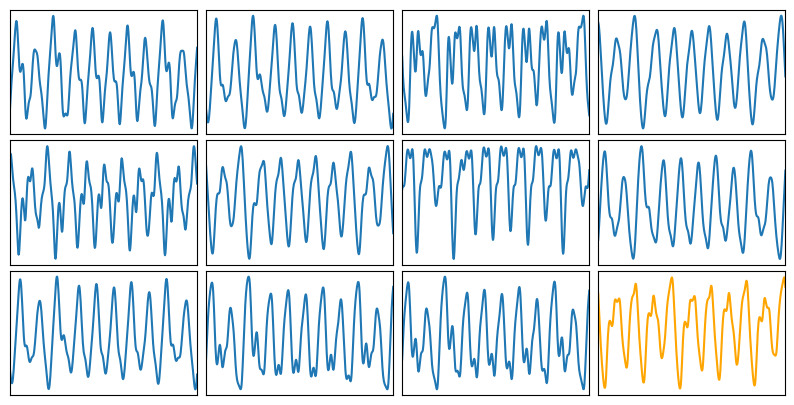

In [5]:
# Plotting the internal units during the training period
fig, ax = plt.subplots(3,4,figsize=(10,5), gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
unit_idx = rng.choice(400,size=[3,4])
print(unit_idx)
for i in range(3):
    for j in range(4):
        if [i,j] == [2,3]: 
            ax[i,j].plot(y_17_3000,color='orange')
            ax[i,j].set_xlim(0,500)
            ax[i,j].set_xticks([])
            ax[i,j].set_yticks([])
            continue
        ax[i,j].plot(X[:,unit_idx[i,j]])
        ax[i,j].set_xlim(0,500)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

Text(0, 0.5, 'weight value')

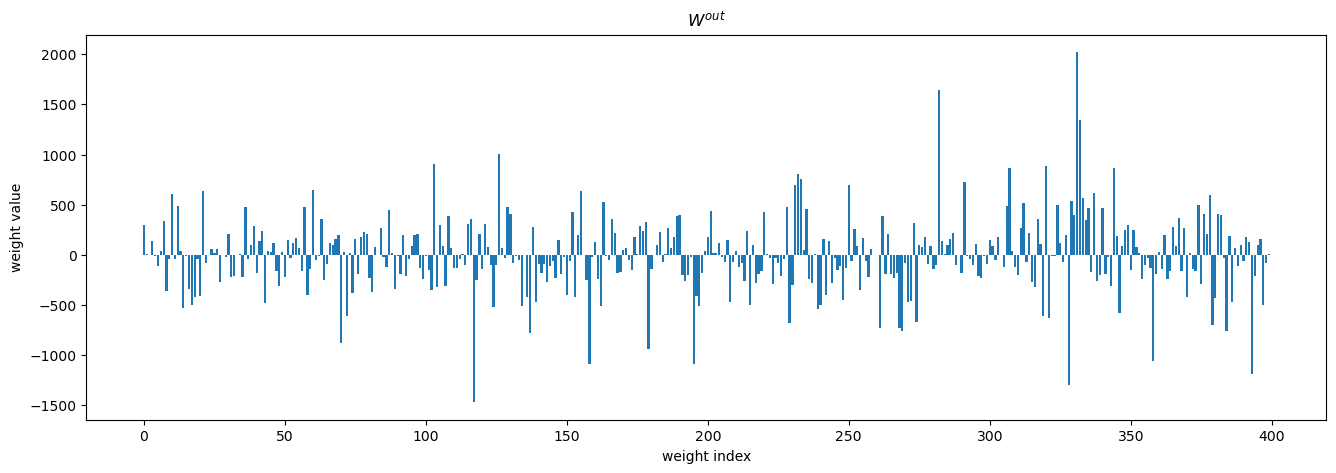

In [6]:
## Plotting the trained output weights
A = np.array(model.coef_)
index = [i for i in range(N)]
plt.figure(figsize=(16,5))
plt.bar(index,A)
plt.title(r'$W^{out}$')
plt.xlabel('weight index')
plt.ylabel('weight value')

In [7]:
#mse train
y_out = model.predict(X)
mse_train = np.mean((y_17_3000_original[washout+1:]-(np.arctanh(y_out)+1))**2)
print(f'mse_train = {mse_train}')

mse_train = 2.7162440569463603e-11


In [8]:
## Test data
y_30_4000_original = MG_series(4000,30)
y_30_4000 = np.tanh(y_30_4000_original-1)

In [9]:
## Testing phase
teacher_forcing = 1000
autonomous = 3000
x = np.zeros([N,1])
u = np.array([[0.2]])
for i in range(teacher_forcing):
    x = T(x,np.concatenate((u,y_30_4000[i].reshape(L,1)),axis=0))

y_pred = np.zeros(autonomous)
y_pred[0] = model.predict(x.reshape(1,-1))[0]
for i in range(autonomous-1):
    x = T(x,np.concatenate((u,y_pred[i].reshape(L,1)),axis=0))
    y_pred[i+1] = model.predict(x.reshape(1,-1))[0]

(0.0, 500.0)

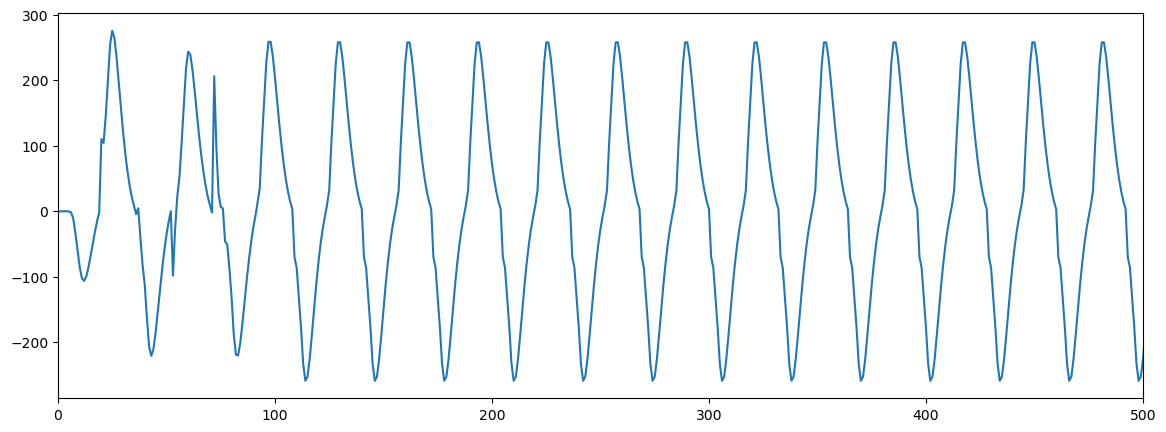

In [12]:
plt.figure(figsize=(14,5))
plt.plot(y_pred)
plt.xlim(0,500)


/tmp/ipykernel_18979/3995018312.py:3: RuntimeWarning: invalid value encountered in arctanh
  plt.plot(np.arctanh(y_pred)+1,label='prediction')


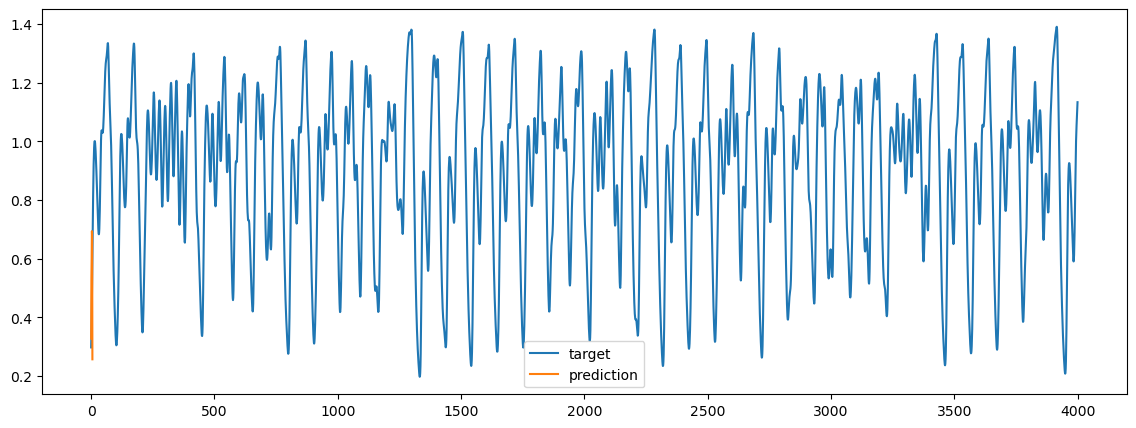

In [10]:
plt.figure(figsize=(14,5))
plt.plot(y_30_4000_original,label='target')
plt.plot(np.arctanh(y_pred)+1,label='prediction')
plt.legend()